<a href="https://colab.research.google.com/github/tamyriscabral/lia1_2026_2/blob/main/Entregas-Tamyris%20Cabral/EcoSort_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ♻️ EcoSort AI — Classificação Inteligente de Resíduos

**Problema real → Dataset → CNN → Classificação → Avaliação → Aplicação na triagem**

Projeto acadêmico para Laboratório de Inovação e Automação com Python e TensorFlow/Keras.

Por Tamyris Cabral

## 1. 🌱 Introdução

Centros de reciclagem hoje dependem fortemente de triagem manual em esteiras: operadores identificam o material a olho e o direcionam para o tratamento correto (reciclagem de plástico, papel, metal, vidro ou compostagem/descarte do orgânico). Esse processo é lento, sujeito a fadiga e erro humano, e itens mal direcionados geram contaminação de lotes recicláveis — reduzindo o valor de revenda do material e aumentando o retrabalho.

O **EcoSort AI** propõe automatizar essa decisão: uma câmera posicionada sobre a esteira captura a imagem do resíduo no momento em que ele passa, e uma Rede Neural Convolucional (CNN) classifica o material em uma das cinco categorias. A classificação aciona o direcionamento físico do item (por exemplo, um separador/atuador na esteira) para a rota de tratamento correspondente — sem depender de um operador decidir em tempo real para cada item.

Este notebook cobre a construção e validação do modelo de classificação. O controle físico do atuador na esteira não é implementado aqui; a seção 11 detalha como a saída do modelo se conectaria a essa decisão operacional.

## 	⚙️ Preparação do ambiente

O dataset utilizado é o [New Trash Classification Dataset](https://www.kaggle.com/datasets/glhdamar/new-trash-classfication-dataset), disponibilizado no Kaggle. O código tenta baixá-lo com `kagglehub`. Caso o download não funcione, coloque a pasta extraída em `data/new-trash-classification-dataset/` ao lado deste notebook e execute as células novamente.

In [57]:
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

SEED = 42
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 32
EPOCHS = 12
CLASS_NAMES = ['plastic', 'paper', 'metal', 'glass', 'organic']
DISPLAY_NAMES = ['Plastic', 'Paper', 'Metal', 'Glass', 'Organic']
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [58]:
# Download opcional via KaggleHub.
# Se a pasta local existir, ela é usada antes de qualquer download.
LOCAL_DATASET_DIR = Path('data/new-trash-classification-dataset')
DATASET_ROOT = None

if LOCAL_DATASET_DIR.exists():
    DATASET_ROOT = LOCAL_DATASET_DIR
    print(f'Dataset local encontrado em: {DATASET_ROOT.resolve()}')
else:
    try:
        import kagglehub
        DATASET_ROOT = Path(kagglehub.dataset_download('glhdamar/new-trash-classfication-dataset'))
        print(f'Dataset baixado/encontrado em cache: {DATASET_ROOT}')
    except Exception as error:
        print('Dataset ainda não disponível.')
        print('Baixe pelo KaggleHub ou coloque os arquivos em:')
        print(LOCAL_DATASET_DIR.resolve())
        print(f'Detalhe: {type(error).__name__}: {error}')

DATASET_READY = DATASET_ROOT is not None and DATASET_ROOT.exists()

Using Colab cache for faster access to the 'new-trash-classfication-dataset' dataset.
Dataset baixado/encontrado em cache: /kaggle/input/new-trash-classfication-dataset


### 2. 🗂️ Dataset

Usaremos apenas as classes **plastic**, **paper**, **metal**, **glass** e **organic**. O código abaixo verifica a estrutura encontrada, localiza as pastas de classes e obtém as quantidades diretamente dos arquivos — nenhum número é informado manualmente.

In [59]:
def find_class_layouts(dataset_root, class_names):
    """Encontra diretórios que possuem as cinco subpastas de classes.

    Também funciona quando o dataset possui divisões como train/ e test/.
    """
    candidates = [dataset_root] + [p for p in dataset_root.rglob('*') if p.is_dir()]
    layouts = []
    for folder in candidates:
        children = {p.name.lower(): p for p in folder.iterdir() if p.is_dir()}
        if all(name in children for name in class_names):
            layouts.append(folder)

    # Mantém layouts mais profundos, evitando contar duas vezes um pai e um filho.
    return [layout for layout in layouts
            if not any(layout != other and layout in other.parents for other in layouts)]

def images_in(folder):
    return sorted(p for p in folder.rglob('*')
                  if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS)

image_paths, image_labels, class_counts = [], [], {}
layout_dirs = []

if DATASET_READY:
    layout_dirs = find_class_layouts(DATASET_ROOT, CLASS_NAMES)
    if not layout_dirs:
        raise FileNotFoundError(
            'Não foram encontradas subpastas para as cinco classes desejadas. '
            'Confira DATASET_ROOT e a estrutura do dataset.'
        )

    print('Estruturas de classes utilizadas:')
    for layout in layout_dirs:
        print(' -', layout)

    seen_paths = set()
    for label, class_name in enumerate(CLASS_NAMES):
        paths_for_class = []
        for layout in layout_dirs:
            for image_path in images_in(layout / class_name):
                if image_path not in seen_paths:
                    seen_paths.add(image_path)
                    paths_for_class.append(image_path)
        image_paths.extend(paths_for_class)
        image_labels.extend([label] * len(paths_for_class))
        class_counts[class_name] = len(paths_for_class)

    if any(count == 0 for count in class_counts.values()):
        raise ValueError('Pelo menos uma das cinco classes não possui imagens válidas.')

    dataset_table = pd.DataFrame({
        'Classe': DISPLAY_NAMES,
        'Imagens': [class_counts[name] for name in CLASS_NAMES]
    })
    display(dataset_table)
    print(f'Total de imagens utilizadas: {len(image_paths)}')
else:
    print('Célula aguardando o dataset. Veja a célula de preparação acima.')

Estruturas de classes utilizadas:
 - /kaggle/input/new-trash-classfication-dataset/new-dataset-trash-type-v2


,Classe,Imagens
0,Plastic,891
1,Paper,853
2,Metal,901
3,Glass,948
4,Organic,967


Total de imagens utilizadas: 4560


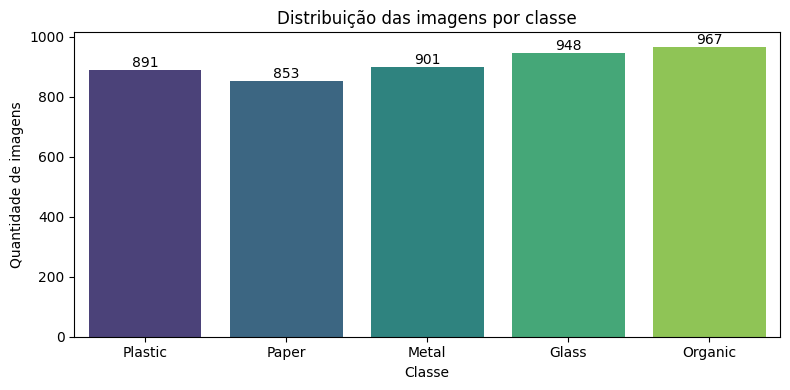

In [60]:
if DATASET_READY:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=dataset_table, x='Classe', y='Imagens', hue='Classe',
                legend=False, palette='viridis', ax=ax)
    ax.set_title('Distribuição das imagens por classe')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Quantidade de imagens')
    for container in ax.containers:
        ax.bar_label(container)
    plt.tight_layout()
    plt.show()

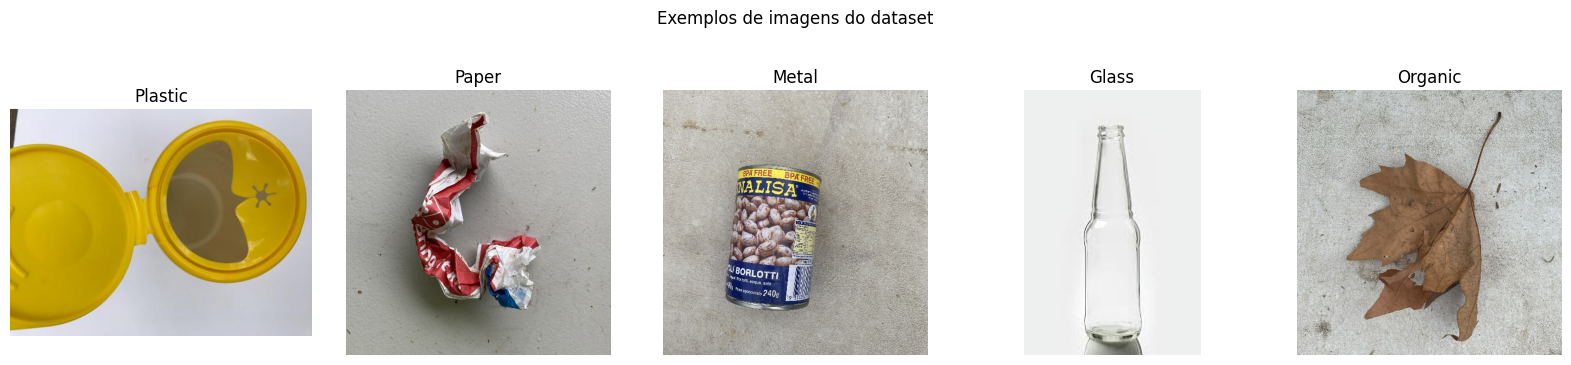

In [61]:
if DATASET_READY:
    # Exemplos reais são sorteados das imagens encontradas no dataset.
    fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(16, 3.5))
    for label, (class_name, display_name) in enumerate(zip(CLASS_NAMES, DISPLAY_NAMES)):
        class_paths = [path for path, current_label in zip(image_paths, image_labels)
                       if current_label == label]
        selected_path = random.choice(class_paths)
        axes[label].imshow(plt.imread(selected_path))
        axes[label].set_title(display_name)
        axes[label].axis('off')
    fig.suptitle('Exemplos de imagens do dataset', y=1.03)
    plt.tight_layout()
    plt.show()

## 3. 	🧹 Pré-processamento

As imagens serão redimensionadas para `160 × 160` pixels e seus valores serão normalizados para o intervalo de 0 a 1. A divisão é estratificada para preservar aproximadamente a proporção das classes: 70% treino, 15% validação e 15% teste.

In [62]:
if DATASET_READY:
    labels_array = np.array(image_labels)
    paths_array = np.array([str(path) for path in image_paths])

    if min(class_counts.values()) < 4:
        raise ValueError('São necessárias pelo menos 4 imagens por classe para a divisão estratificada.')

    train_paths, temporary_paths, train_labels, temporary_labels = train_test_split(
        paths_array, labels_array, test_size=0.30, stratify=labels_array, random_state=SEED
    )
    val_paths, test_paths, val_labels, test_labels = train_test_split(
        temporary_paths, temporary_labels, test_size=0.50,
        stratify=temporary_labels, random_state=SEED
    )

    split_table = pd.DataFrame({
        'Conjunto': ['Treinamento', 'Validação', 'Teste'],
        'Imagens': [len(train_paths), len(val_paths), len(test_paths)],
        'Proporção': [f'{len(train_paths)/len(paths_array):.1%}',
                      f'{len(val_paths)/len(paths_array):.1%}',
                      f'{len(test_paths)/len(paths_array):.1%}']
    })
    display(split_table)

    def load_and_preprocess(image_path, label):
        image = tf.io.read_file(image_path)
        image = tf.io.decode_image(image, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])
        image = tf.image.resize(image, IMAGE_SIZE)
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    def make_dataset(paths, labels, training=False):
        dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
        if training:
            dataset = dataset.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
        return (dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
                       .batch(BATCH_SIZE)
                       .prefetch(tf.data.AUTOTUNE))

    train_ds = make_dataset(train_paths, train_labels, training=True)
    val_ds = make_dataset(val_paths, val_labels)
    test_ds = make_dataset(test_paths, test_labels)
    print('Datasets TensorFlow prontos para treinamento.')

,Conjunto,Imagens,Proporção
0,Treinamento,3192,70.0%
1,Validação,684,15.0%
2,Teste,684,15.0%


Datasets TensorFlow prontos para treinamento.


## 4. 🖼️ Visualização

A seguir, algumas imagens já redimensionadas e normalizadas que serão entregues à CNN.

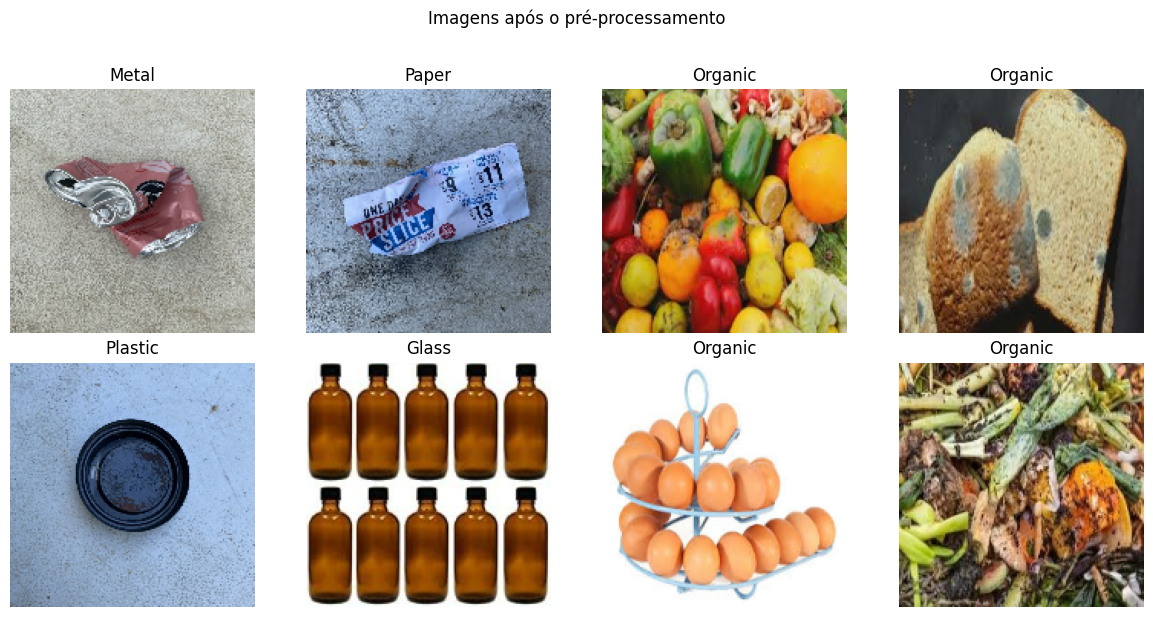

In [63]:
if DATASET_READY:
    images_batch, labels_batch = next(iter(train_ds))
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for image, label, ax in zip(images_batch[:8], labels_batch[:8], axes.flat):
        ax.imshow(image.numpy())
        ax.set_title(DISPLAY_NAMES[int(label)])
        ax.axis('off')
    fig.suptitle('Imagens após o pré-processamento', y=1.02)
    plt.tight_layout()
    plt.show()

## 5. 🧠 Construção do modelo

Em vez de treinar uma CNN do zero, o modelo parte de uma rede já pré-treinada na ImageNet, a **MobileNetV2**, usada como extratora de características (`include_top=False`). Essa base já reconhece padrões visuais genéricos como bordas, texturas e reflexos — muito úteis para diferenciar materiais como plástico, metal e vidro.

Antes de entrar na base, as imagens passam por uma camada de **data augmentation** (flip horizontal, rotação, zoom e variação de contraste), que simula ângulos e iluminações diferentes e ajuda o modelo a generalizar com o volume de dados disponível.

Sobre a saída da base, uma camada `GlobalAveragePooling2D` resume os mapas de características, seguida por uma camada `Dense` intermediária, `Dropout` para regularização e a camada final `Dense` com ativação `softmax`, que classifica a imagem em uma das cinco categorias.

In [64]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # fase 1: só treina a "cabeça"

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
])

inputs = tf.keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)  # espera [-1, 1]
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(5, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_1 (Multiply)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,293 (8.93 MB)

 Trainable params: 82,309 (321.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. 🏋️ Treinamento

O treinamento é feito em **duas fases**:

1. **Fase 1 — cabeça treinável, base congelada:** os pesos da MobileNetV2 ficam fixos (`base_model.trainable = False`) e apenas as camadas adicionadas ao final aprendem a mapear as características extraídas para as cinco classes de resíduo.
2. **Fase 2 — fine-tuning:** as últimas camadas da base são descongeladas e o modelo inteiro é reajustado com uma taxa de aprendizado bem baixa, permitindo que os filtros pré-treinados se especializem no domínio de resíduos sem perder o conhecimento geral aprendido na ImageNet.

Os callbacks `EarlyStopping` (interrompe o treino se a validação parar de melhorar e restaura os melhores pesos) e `ReduceLROnPlateau` (reduz a taxa de aprendizado quando a perda de validação estagna) são usados nas duas fases. Os históricos retornados por `model.fit()` são combinados e usados nos gráficos da próxima seção.

In [65]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=4, mode="max", restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2
)

# Fase 1: só a cabeça treina, base congelada
history = model.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

# Fase 2: fine-tuning — descongela as últimas camadas da base
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.6626 - loss: 0.8681 - val_accuracy: 0.7953 - val_loss: 0.5861 - learning_rate: 0.0010
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.7845 - loss: 0.5755 - val_accuracy: 0.8304 - val_loss: 0.4708 - learning_rate: 0.0010
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8242 - loss: 0.4805 - val_accuracy: 0.8392 - val_loss: 0.4484 - learning_rate: 0.0010
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.8396 - loss: 0.4317 - val_accuracy: 0.8319 - val_loss: 0.4376 - learning_rate: 0.0010
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8565 - loss: 0.3920 - val_accuracy: 0.8494 - val_loss: 0.4155 - learning_rate: 0.0010
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8634 - loss: 0.3691 - val_accuracy: 0.8582 - val_loss: 0.4055 - learning_rate: 0.0010
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8750 - loss: 

## 7. 📈 Resultados do treinamento

Os gráficos permitem comparar treino e validação. Uma diferença crescente entre as curvas pode indicar overfitting; a interpretação abaixo é calculada a partir da última época executada.

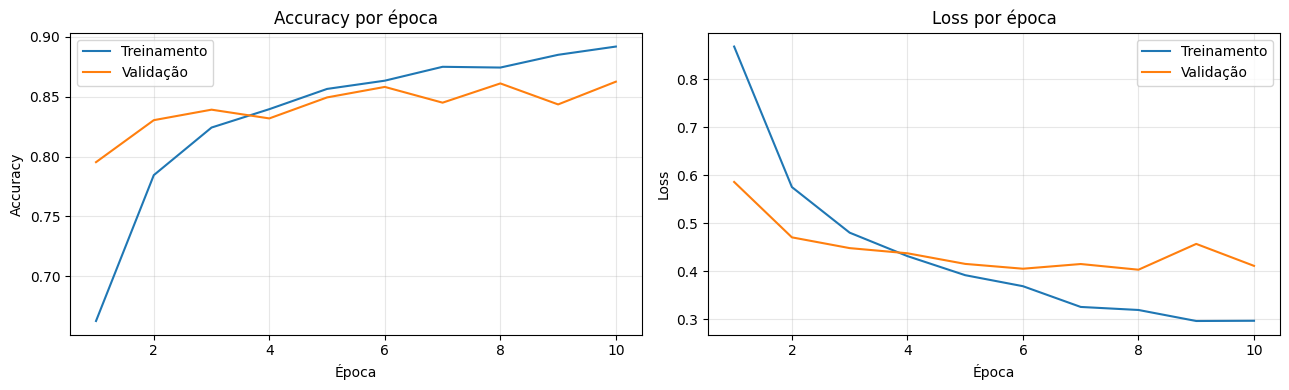

Última época — accuracy de treino: 0.892; validação: 0.863
Não há um forte indício de overfitting pela comparação final; observe também o formato das curvas.


In [66]:
if DATASET_READY:
    epochs_range = range(1, len(history.history['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs_range, history.history['accuracy'], label='Treinamento')
    axes[0].plot(epochs_range, history.history['val_accuracy'], label='Validação')
    axes[0].set_title('Accuracy por época')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history.history['loss'], label='Treinamento')
    axes[1].plot(epochs_range, history.history['val_loss'], label='Validação')
    axes[1].set_title('Loss por época')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    accuracy_gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
    loss_gap = history.history['val_loss'][-1] - history.history['loss'][-1]
    print(f'Última época — accuracy de treino: {history.history["accuracy"][-1]:.3f}; '
          f'validação: {history.history["val_accuracy"][-1]:.3f}')
    if accuracy_gap > 0.10 and loss_gap > 0:
        print('Há indício de overfitting: o desempenho de treino ficou consideravelmente acima da validação.')
    else:
        print('Não há um forte indício de overfitting pela comparação final; observe também o formato das curvas.')

## 8. 	✅ Avaliação

Agora o modelo é avaliado uma única vez no conjunto de teste, que não participou do treinamento nem da validação.

In [67]:
if DATASET_READY:
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    y_probabilities = model.predict(test_ds, verbose=0)
    y_predicted = np.argmax(y_probabilities, axis=1)
    y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_predicted, average='weighted', zero_division=0
    )
    print(f'Test Loss:     {test_loss:.4f}')
    print(f'Test Accuracy: {test_accuracy:.2%}')
    print(f'Precision (ponderada): {precision:.2%}')
    print(f'Recall (ponderado):    {recall:.2%}')
    print(f'F1-score (ponderado):  {f1:.2%}')

    print('\nRelatório por classe:')
    print(classification_report(y_true, y_predicted, target_names=DISPLAY_NAMES, zero_division=0))

Test Loss:     0.4512
Test Accuracy: 85.38%
Precision (ponderada): 85.71%
Recall (ponderado):    85.38%
F1-score (ponderado):  85.44%

Relatório por classe:
              precision    recall  f1-score   support

     Plastic       0.72      0.78      0.75       134
       Paper       0.91      0.92      0.91       128
       Metal       0.82      0.85      0.83       135
       Glass       0.88      0.77      0.82       142
     Organic       0.96      0.94      0.95       145

    accuracy                           0.85       684
   macro avg       0.86      0.85      0.85       684
weighted avg       0.86      0.85      0.85       684



## 9. 🔀 Matriz de confusão

A diagonal representa previsões corretas. Valores fora dela mostram quais materiais foram confundidos entre si. A interpretação é gerada a partir dos resultados obtidos nesta execução.

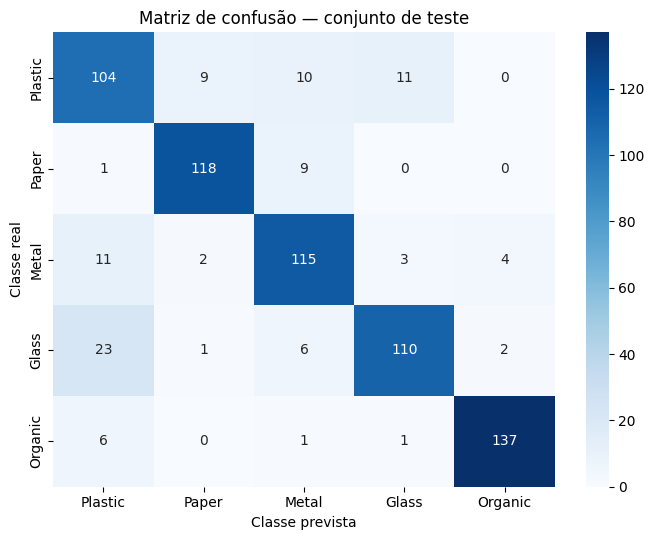

Melhor identificada: Organic (recall: 94.5%).
Maior confusão: Glass classificado como Plastic (23 imagem(ns)).


In [68]:
if DATASET_READY:
    confusion = confusion_matrix(y_true, y_predicted, labels=range(len(CLASS_NAMES)))
    plt.figure(figsize=(7, 5.5))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
                xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES)
    plt.title('Matriz de confusão — conjunto de teste')
    plt.xlabel('Classe prevista')
    plt.ylabel('Classe real')
    plt.tight_layout()
    plt.show()

    per_class_recall = np.diag(confusion) / np.maximum(confusion.sum(axis=1), 1)
    best_index = int(np.argmax(per_class_recall))
    print(f'Melhor identificada: {DISPLAY_NAMES[best_index]} '
          f'(recall: {per_class_recall[best_index]:.1%}).')

    off_diagonal = confusion.copy()
    np.fill_diagonal(off_diagonal, 0)
    if off_diagonal.max() > 0:
        real_index, predicted_index = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)
        print(f'Maior confusão: {DISPLAY_NAMES[real_index]} classificado como '
              f'{DISPLAY_NAMES[predicted_index]} ({off_diagonal[real_index, predicted_index]} imagem(ns)).')
    else:
        print('Não houve confusões no conjunto de teste desta execução.')

## 10. 🔍 Inferência

A demonstração seleciona imagens do conjunto de teste e mostra a classe prevista e a confiança calculada pelo modelo.

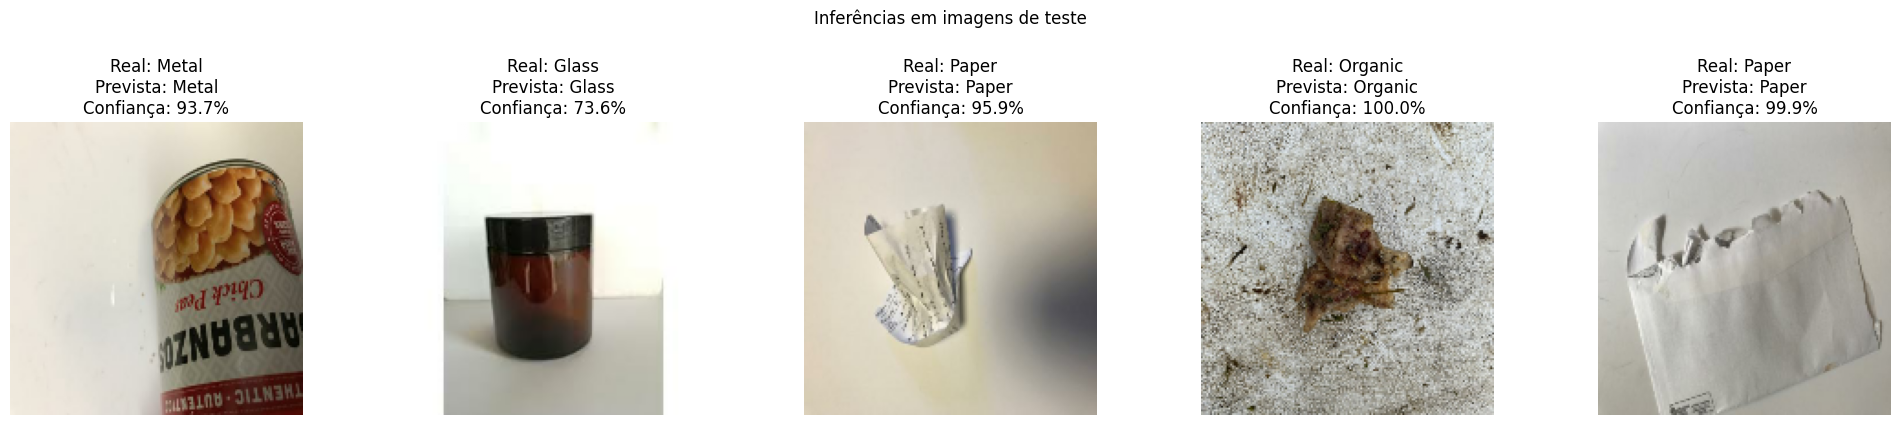

In [69]:
if DATASET_READY:
    number_of_examples = min(5, len(test_paths))
    chosen_indices = np.random.choice(len(test_paths), size=number_of_examples, replace=False)
    fig, axes = plt.subplots(1, number_of_examples, figsize=(4 * number_of_examples, 4))
    axes = np.atleast_1d(axes)

    for ax, index in zip(axes, chosen_indices):
        image, true_label = load_and_preprocess(test_paths[index], test_labels[index])
        probabilities = model.predict(tf.expand_dims(image, axis=0), verbose=0)[0]
        predicted_label = int(np.argmax(probabilities))
        confidence = probabilities[predicted_label]

        ax.imshow(image.numpy())
        ax.set_title(f'Real: {DISPLAY_NAMES[int(true_label)]}\n'
                     f'Prevista: {DISPLAY_NAMES[predicted_label]}\n'
                     f'Confiança: {confidence:.1%}')
        ax.axis('off')

    fig.suptitle('Inferências em imagens de teste', y=1.05)
    plt.tight_layout()
    plt.show()

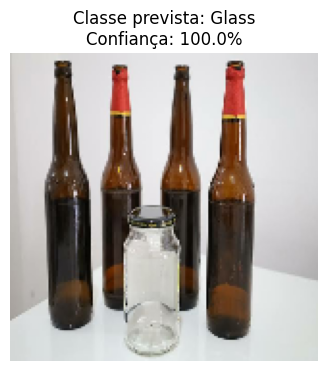

In [70]:
# Inferência de uma imagem externa (opcional).
# Informe o caminho de uma imagem, por exemplo: EXTERNAL_IMAGE_PATH = 'minha_imagem.jpg'
EXTERNAL_IMAGE_PATH = 'images.jpg'

if DATASET_READY and EXTERNAL_IMAGE_PATH:
    external_path = Path(EXTERNAL_IMAGE_PATH)
    if not external_path.exists():
        raise FileNotFoundError(f'Imagem não encontrada: {external_path}')

    image, _ = load_and_preprocess(str(external_path), 0)
    probabilities = model.predict(tf.expand_dims(image, axis=0), verbose=0)[0]
    predicted_label = int(np.argmax(probabilities))

    plt.figure(figsize=(4, 4))
    plt.imshow(image.numpy())
    plt.axis('off')
    plt.title(f'Classe prevista: {DISPLAY_NAMES[predicted_label]}\n'
              f'Confiança: {probabilities[predicted_label]:.1%}')
    plt.show()
elif DATASET_READY:
    print('Para testar uma imagem externa, preencha EXTERNAL_IMAGE_PATH com um caminho válido.')

## 11. 🏭 Aplicação do produto

**Problema real:** triagem manual em esteiras de centros de reciclagem é lenta e sujeita a erro, gerando contaminação de lotes recicláveis e retrabalho.

**Fluxo proposto na esteira:**

```text
Câmera sobre a esteira
   ↓
Imagem do resíduo capturada em tempo real
   ↓
CNN classifica: Plastic / Paper / Metal / Glass / Organic
   ↓
Confiança da previsão é avaliada
   ↓
Alta confiança → atuador direciona o item para a rota correta
Baixa confiança → item é desviado para uma esteira secundária de revisão manual
```

**Por que a revisão manual importa:** a matriz de confusão (seção 9) mostra que Plastic, Metal e Glass ainda são confundidos entre si em alguns casos. Em vez de forçar uma decisão automática sempre, um limiar de confiança (ex.: abaixo de 70%) evita que o modelo direcione errado um item ambíguo — o item vai para um operador humano decidir, em vez de contaminar o lote errado.

**O que mudaria na operação:** hoje um operador decide para todo item que passa na esteira; com o EcoSort AI, o operador só precisa decidir os casos que o modelo sinaliza como incertos, liberando tempo para os itens mais difíceis.

**Métrica de sucesso, se implantado:** redução da taxa de contaminação por lote reciclável (itens no lote errado) e redução do tempo médio de triagem por item — o modelo é o mesmo, mas o impacto só existe se essas métricas melhorarem na operação real.

**Limitação importante:** este notebook classifica imagens estáticas de teste; não há controle físico de atuadores implementado, nem validação com imagens reais capturadas em uma esteira em movimento (iluminação, ângulo e velocidade diferentes do dataset usado aqui).

## 12. ⚠️ Limitações

- O desempenho depende da qualidade, variedade e equilíbrio das imagens do dataset.
- Imagens de uma esteira real podem ter iluminação, fundos e ângulos diferentes.
- Materiais visualmente semelhantes podem ser confundidos.
- A classificação não é perfeita e deve ser validada antes de qualquer uso operacional.

## 13. 	🏁 Conclusão

Foi desenvolvido um pipeline de classificação de imagens usando **transfer learning** com a MobileNetV2 pré-treinada, combinada com data augmentation e fine-tuning em duas fases: carregamento do dataset, pré-processamento, treinamento, validação, teste, matriz de confusão e inferência. O desempenho obtido é mostrado na seção de avaliação após a execução.

A principal dificuldade é fazer o modelo generalizar para imagens variadas de resíduos. Mesmo assim, o experimento demonstra como a visão computacional pode transformar uma imagem em uma informação útil para apoiar a separação de materiais em uma triagem.